In [116]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

In [117]:
df = pd.read_csv("churn_cleaned.csv")
df.head()


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [118]:
df.shape

(7043, 21)

In [119]:
df.dtypes

customerID              str
gender                  str
SeniorCitizen         int64
Partner                 str
Dependents              str
tenure                int64
PhoneService            str
MultipleLines           str
InternetService         str
OnlineSecurity          str
OnlineBackup            str
DeviceProtection        str
TechSupport             str
StreamingTV             str
StreamingMovies         str
Contract                str
PaperlessBilling        str
PaymentMethod           str
MonthlyCharges      float64
TotalCharges        float64
Churn                   str
dtype: object

In [120]:
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [121]:
df.duplicated().sum()

np.int64(0)

In [122]:
#TotalCharges column has blank spaces - convert it to number
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')


# Fill missing values in 'TotalCharges' with the median
df['TotalCharges'] = df['TotalCharges'].fillna(df['TotalCharges'].median())

df = df.drop_duplicates()

df.to_csv('churn_cleaned.csv', index=False)

In [123]:
# Make a copy for machine learning work
df_ml = df.copy()

In [124]:
df_ml['Churn'] = df_ml['Churn'].map({'Yes': 1, 'No': 0})

# Removing customerID as it is not useful for machine learning
df_ml = df_ml.drop('customerID', axis=1, errors='ignore')

# Converting gender to numeric values (Male: 1, Female: 0)
df_ml['gender'] = df_ml['gender'].map({'Male': 1, 'Female': 0})


In [125]:
# Encode simple Yes/No columns to 1 and 0
df_ml['Partner']          = df_ml['Partner'].map({'Yes': 1, 'No': 0})
df_ml['Dependents']       = df_ml['Dependents'].map({'Yes': 1, 'No': 0})
df_ml['PhoneService']     = df_ml['PhoneService'].map({'Yes': 1, 'No': 0})
df_ml['PaperlessBilling'] = df_ml['PaperlessBilling'].map({'Yes': 1, 'No': 0})

# Encode service columns
# These have 3 values: Yes, No, No phone service / No internet service
df_ml['MultipleLines']    = df_ml['MultipleLines'].map({'Yes': 1, 'No': 0, 'No phone service': 0})
df_ml['OnlineSecurity']   = df_ml['OnlineSecurity'].map({'Yes': 1, 'No': 0, 'No internet service': 0})
df_ml['OnlineBackup']     = df_ml['OnlineBackup'].map({'Yes': 1, 'No': 0, 'No internet service': 0})
df_ml['DeviceProtection'] = df_ml['DeviceProtection'].map({'Yes': 1, 'No': 0, 'No internet service': 0})
df_ml['TechSupport']      = df_ml['TechSupport'].map({'Yes': 1, 'No': 0, 'No internet service': 0})
df_ml['StreamingTV']      = df_ml['StreamingTV'].map({'Yes': 1, 'No': 0, 'No internet service': 0})
df_ml['StreamingMovies']  = df_ml['StreamingMovies'].map({'Yes': 1, 'No': 0, 'No internet service': 0})

In [126]:
# One-hot encode remaining text columns (InternetService, Contract, PaymentMethod)
cols_to_encode = [c for c in ['InternetService', 'Contract', 'PaymentMethod'] if c in df_ml.columns]
if cols_to_encode:
    df_ml = pd.get_dummies(df_ml, columns=cols_to_encode)

#Convert True/False columns to 1 and 0
for col in df_ml.columns:
    if df_ml[col].dtype == bool:
        df_ml[col] = df_ml[col].astype(int)

#Fill any leftover missing values with 0
df_ml = df_ml.fillna(0)

In [127]:
# Scale the numerical columns so they are on same range
scaler = StandardScaler()
df_ml['tenure']         = scaler.fit_transform(df_ml[['tenure']])
df_ml['MonthlyCharges'] = scaler.fit_transform(df_ml[['MonthlyCharges']])
df_ml['TotalCharges']   = scaler.fit_transform(df_ml[['TotalCharges']])

# Separate features (X) and target (y)
X = df_ml.drop('Churn', axis=1)
y = df_ml['Churn']

# Split data into 80% training and 20% testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [128]:
# Split data into 80% training and 20% testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [129]:
# EXPLORATORY DATA ANALYSIS (EDA)

# Q1: What percentage of customers have churned?
total_customers    = len(df)
churned_customers  = (df['Churn'] == 'Yes').sum()
retained_customers = (df['Churn'] == 'No').sum()
churn_percentage   = round(churned_customers / total_customers * 100, 1)

# Q2: Which contract type has the highest churn?
month_to_month_df = df[df['Contract'] == 'Month-to-month']
one_year_df       = df[df['Contract'] == 'One year']
two_year_df       = df[df['Contract'] == 'Two year']

mtm_churn_rate = round((month_to_month_df['Churn'] == 'Yes').mean() * 100, 1)
oy_churn_rate  = round((one_year_df['Churn'] == 'Yes').mean() * 100, 1)
ty_churn_rate  = round((two_year_df['Churn'] == 'Yes').mean() * 100, 1)

# Q3: Does monthly charge impact churn?
avg_charge_churned  = round(df[df['Churn'] == 'Yes']['MonthlyCharges'].mean(), 2)
avg_charge_retained = round(df[df['Churn'] == 'No']['MonthlyCharges'].mean(), 2)
charge_difference   = round(avg_charge_churned - avg_charge_retained, 2)

# Q4: Which features correlate most with churn?
correlation  = df_ml.corr()['Churn'].drop('Churn')
correlation  = correlation.abs()
correlation  = correlation.sort_values(ascending=False)
top_features = correlation.head(10)

In [130]:
# Model 1: Random Forest
model_rf = RandomForestClassifier(n_estimators=100, random_state=42)
model_rf.fit(X_train, y_train)
pred_rf = model_rf.predict(X_test)

# Model 2: Decision Tree
model_dt = DecisionTreeClassifier(max_depth=6, random_state=42)
model_dt.fit(X_train, y_train)
pred_dt = model_dt.predict(X_test)

# Decision Tree - Evaluation
acc_dt  = round(accuracy_score(y_test, pred_dt) * 100, 2)
prec_dt = round(precision_score(y_test, pred_dt, zero_division=0) * 100, 2)
rec_dt  = round(recall_score(y_test, pred_dt, zero_division=0) * 100, 2)
f1_dt   = round(f1_score(y_test, pred_dt, zero_division=0) * 100, 2)
cm_dt   = confusion_matrix(y_test, pred_dt)

# Random Forest - Evaluation
acc_rf  = round(accuracy_score(y_test, pred_rf) * 100, 2)
prec_rf = round(precision_score(y_test, pred_rf, zero_division=0) * 100, 2)
rec_rf  = round(recall_score(y_test, pred_rf, zero_division=0) * 100, 2)
f1_rf   = round(f1_score(y_test, pred_rf, zero_division=0) * 100, 2)
cm_rf   = confusion_matrix(y_test, pred_rf)

In [131]:
print(f"Decision Tree - Accuracy: {acc_dt}%, Precision: {prec_dt}%, Recall: {rec_dt}%, F1 Score: {f1_dt}%")
print(f"Random Forest - Accuracy: {acc_rf}%, Precision: {prec_rf}%, Recall: {rec_rf}%, F1 Score: {f1_rf}%")
print("Decision Tree confusion matrix:")
print(cm_dt)
print("Random Forest confusion matrix:")
print(cm_rf)

Decision Tree - Accuracy: 81.05%, Precision: 67.91%, Recall: 53.89%, F1 Score: 60.09%
Random Forest - Accuracy: 79.63%, Precision: 65.69%, Recall: 48.26%, F1 Score: 55.64%
Decision Tree confusion matrix:
[[941  95]
 [172 201]]
Random Forest confusion matrix:
[[942  94]
 [193 180]]


In [132]:
# PART 5 - BUSINESS RECOMMENDATIONS
# Based on the analysis findings above

# 1. Month-to-month customers churn the most (around 42%)
#    Recommendation: Offer discounts to switch to yearly or 2-year plans

# 2. Fiber optic customers churn the most among internet service types
#    Recommendation: Improve fiber optic service quality and resolve complaints

# 3. New customers (low tenure) leave early
#    Recommendation: Create loyalty rewards for customers in first 6 months

# 4. Churned customers pay higher monthly charges
#    Recommendation: Offer better value bundles for high-paying customers

# 5. Electronic check payment users churn more
#    Recommendation: Encourage customers to switch to auto-pay with a discount

Chart 1: Churn vs Retained Customers
Churned Customers  : 1869
Retained Customers : 5174
Churn Percentage   : 26.5 %



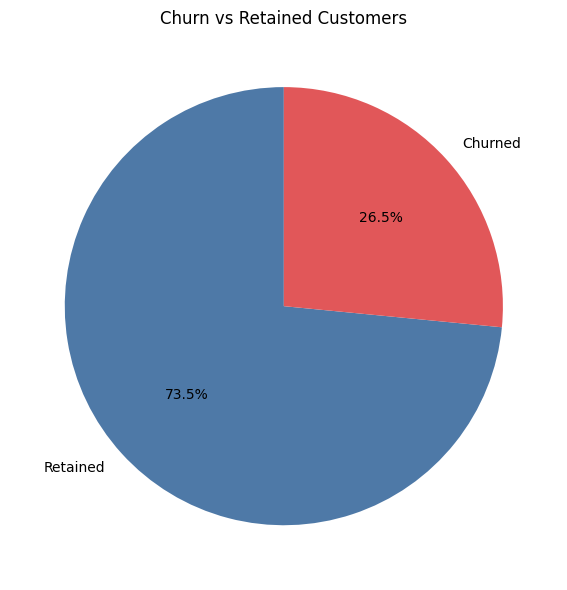

In [133]:
# CHART 1: Churn vs Retained Customers (Pie Chart)

print("Chart 1: Churn vs Retained Customers")
print("Churned Customers  :", churned_customers)
print("Retained Customers :", retained_customers)
print("Churn Percentage   :", churn_percentage, "%")
print()

plt.figure(figsize=(6, 6))
plt.pie([retained_customers, churned_customers],
        labels=['Retained', 'Churned'],
        autopct='%1.1f%%',
        colors=['#4e79a7', '#e15759'],
        startangle=90)
plt.title("Churn vs Retained Customers")
plt.tight_layout()
plt.show()

Chart 2: Churn Rate by Contract Type
Month-to-Month Contract Churn Rate : 42.7 %
One Year Contract Churn Rate        : 11.3 %
Two Year Contract Churn Rate        : 2.8 %



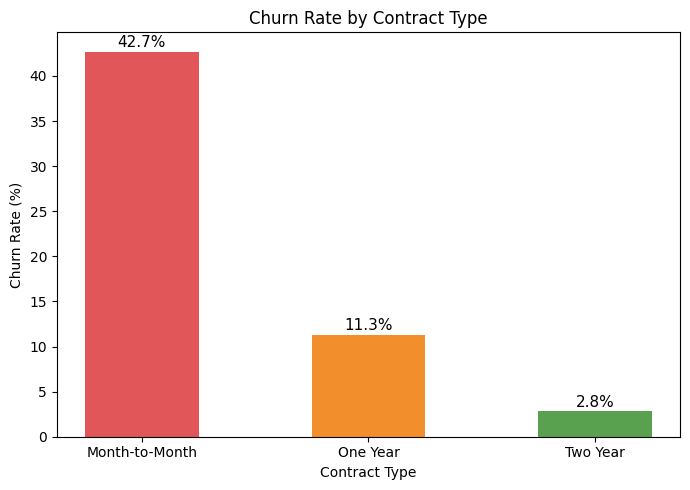

In [134]:
# CHART 2: Churn Rate by Contract Type (Bar Chart)

print("Chart 2: Churn Rate by Contract Type")
print("Month-to-Month Contract Churn Rate :", mtm_churn_rate, "%")
print("One Year Contract Churn Rate        :", oy_churn_rate, "%")
print("Two Year Contract Churn Rate        :", ty_churn_rate, "%")
print()

contract_labels = ['Month-to-Month', 'One Year', 'Two Year']
contract_values = [mtm_churn_rate, oy_churn_rate, ty_churn_rate]

plt.figure(figsize=(7, 5))
plt.bar(contract_labels, contract_values, color=['#e15759', '#f28e2b', '#59a14f'], width=0.5)
plt.title("Churn Rate by Contract Type")
plt.xlabel("Contract Type")
plt.ylabel("Churn Rate (%)")
for i in range(len(contract_values)):
    plt.text(i, contract_values[i] + 0.5, str(contract_values[i]) + "%", ha='center', fontsize=11)
plt.tight_layout()
plt.show()

Chart 3: Average Monthly Charges
Avg Monthly Charge (Churned)   : $ 74.44
Avg Monthly Charge (Retained)  : $ 61.27
Difference                     : $ 13.17 higher for churners



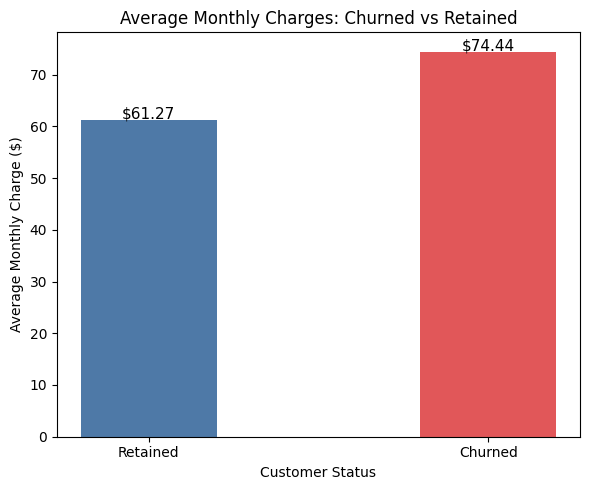

In [135]:
# CHART 3: Average Monthly Charges - Churned vs Retained (Bar Chart)

print("Chart 3: Average Monthly Charges")
print("Avg Monthly Charge (Churned)   : $", avg_charge_churned)
print("Avg Monthly Charge (Retained)  : $", avg_charge_retained)
print("Difference                     : $", charge_difference, "higher for churners")
print()

charge_labels = ['Retained', 'Churned']
charge_values = [avg_charge_retained, avg_charge_churned]

plt.figure(figsize=(6, 5))
plt.bar(charge_labels, charge_values, color=['#4e79a7', '#e15759'], width=0.4)
plt.title("Average Monthly Charges: Churned vs Retained")
plt.xlabel("Customer Status")
plt.ylabel("Average Monthly Charge ($)")
for i in range(len(charge_values)):
    plt.text(i, charge_values[i] + 0.3, "$" + str(charge_values[i]), ha='center', fontsize=11)
plt.tight_layout()
plt.show()

Chart 4: Tenure Distribution
Avg Tenure (Churned)   : 18.0 months
Avg Tenure (Retained)  : 37.6 months



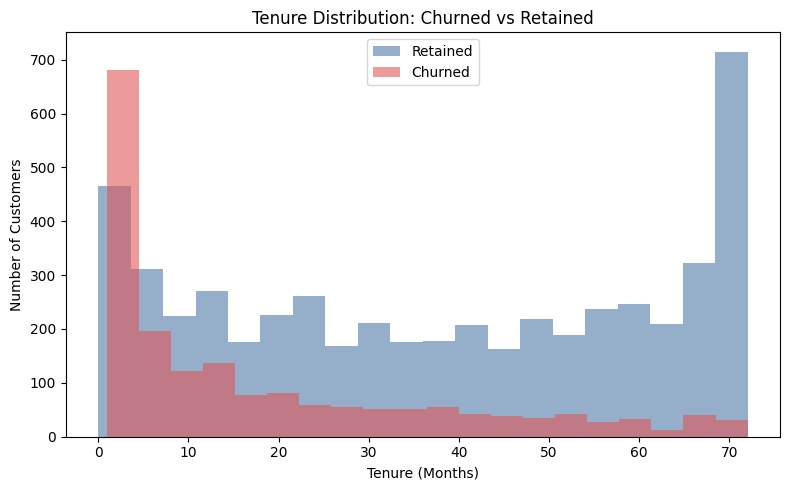

In [136]:
# CHART 4: Tenure Distribution - Churned vs Retained (Histogram)

tenure_churned  = df[df['Churn'] == 'Yes']['tenure']
tenure_retained = df[df['Churn'] == 'No']['tenure']

# compute average tenure values to avoid NameError
avg_tenure_churned  = round(tenure_churned.mean(), 1)
avg_tenure_retained = round(tenure_retained.mean(), 1)

print("Chart 4: Tenure Distribution")
print("Avg Tenure (Churned)   :", avg_tenure_churned, "months")
print("Avg Tenure (Retained)  :", avg_tenure_retained, "months")
print()

plt.figure(figsize=(8, 5))
plt.hist(tenure_retained, bins=20, alpha=0.6, color='#4e79a7', label='Retained')
plt.hist(tenure_churned,  bins=20, alpha=0.6, color='#e15759', label='Churned')
plt.title("Tenure Distribution: Churned vs Retained")
plt.xlabel("Tenure (Months)")
plt.ylabel("Number of Customers")
plt.legend()
plt.tight_layout()
plt.show()

Chart 5: Churn Rate by Internet Service
DSL Churn Rate         : 19.0 %
Fiber Optic Churn Rate : 41.9 %
No Internet Churn Rate : 7.4 %



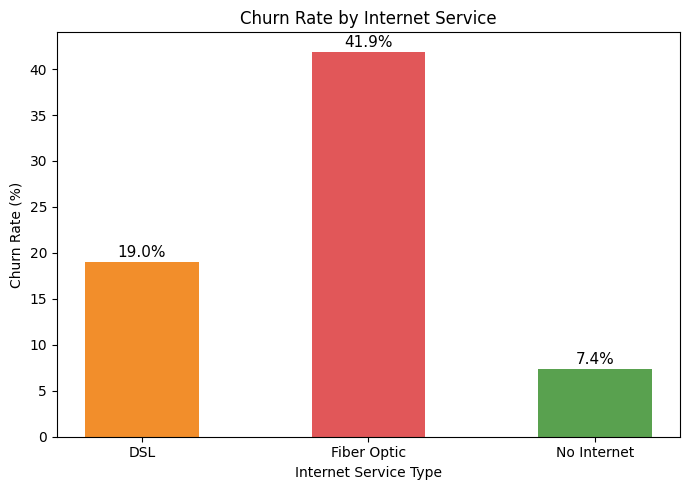

In [137]:
# CHART 5: Churn Rate by Internet Service (Bar Chart)

# Calculate churn rates for each internet service type
dsl_df = df[df['InternetService'] == 'DSL']
fiber_df = df[df['InternetService'] == 'Fiber optic']
noint_df = df[df['InternetService'] == 'No']

dsl_churn_rate = round((dsl_df['Churn'] == 'Yes').mean() * 100, 1)
fiber_churn_rate = round((fiber_df['Churn'] == 'Yes').mean() * 100, 1)
noint_churn_rate = round((noint_df['Churn'] == 'Yes').mean() * 100, 1)

print("Chart 5: Churn Rate by Internet Service")
print("DSL Churn Rate         :", dsl_churn_rate, "%")
print("Fiber Optic Churn Rate :", fiber_churn_rate, "%")
print("No Internet Churn Rate :", noint_churn_rate, "%")
print()

internet_labels = ['DSL', 'Fiber Optic', 'No Internet']
internet_values = [dsl_churn_rate, fiber_churn_rate, noint_churn_rate]

plt.figure(figsize=(7, 5))
plt.bar(internet_labels, internet_values, color=['#f28e2b', '#e15759', '#59a14f'], width=0.5)
plt.title("Churn Rate by Internet Service")
plt.xlabel("Internet Service Type")
plt.ylabel("Churn Rate (%)")
for i in range(len(internet_values)):
    plt.text(i, internet_values[i] + 0.5, str(internet_values[i]) + "%", ha='center', fontsize=11)
plt.tight_layout()
plt.show()

Chart 8: Confusion Matrix - Decision Tree
Accuracy  : 81.05 %
Precision : 67.91 %
Recall    : 53.89 %
F1 Score  : 60.09 %
[[941  95]
 [172 201]]



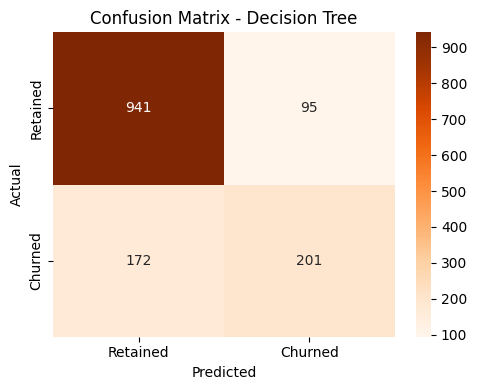

In [138]:
# CHART 6: Confusion Matrix - Decision Tree

print("Chart 8: Confusion Matrix - Decision Tree")
print("Accuracy  :", acc_dt, "%")
print("Precision :", prec_dt, "%")
print("Recall    :", rec_dt, "%")
print("F1 Score  :", f1_dt, "%")
print(cm_dt)
print()

plt.figure(figsize=(5, 4))
sns.heatmap(cm_dt, annot=True, fmt='d', cmap='Oranges',
            xticklabels=['Retained', 'Churned'],
            yticklabels=['Retained', 'Churned'])
plt.title("Confusion Matrix - Decision Tree")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()

Chart 7: Confusion Matrix - Random Forest
Accuracy  : 79.63 %
Precision : 65.69 %
Recall    : 48.26 %
F1 Score  : 55.64 %
[[942  94]
 [193 180]]



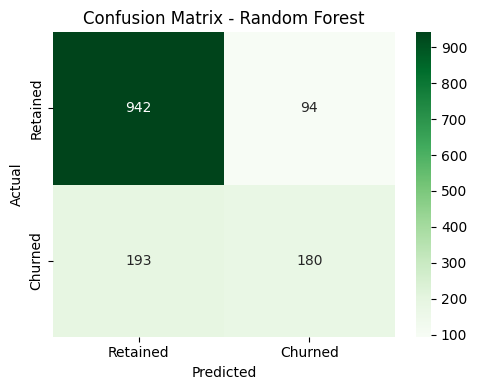

In [139]:
# CHART 7: Confusion Matrix - Random Forest

print("Chart 7: Confusion Matrix - Random Forest")
print("Accuracy  :", acc_rf, "%")
print("Precision :", prec_rf, "%")
print("Recall    :", rec_rf, "%")
print("F1 Score  :", f1_rf, "%")
print(cm_rf)
print()

plt.figure(figsize=(5, 4))
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Greens',
            xticklabels=['Retained', 'Churned'],
            yticklabels=['Retained', 'Churned'])
plt.title("Confusion Matrix - Random Forest")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()

--- Chart 8: Model Comparison ---
Model                Accuracy   F1 Score
Decision Tree       : 81.05 % | 60.09 %
Random Forest       : 79.63 % | 55.64 %



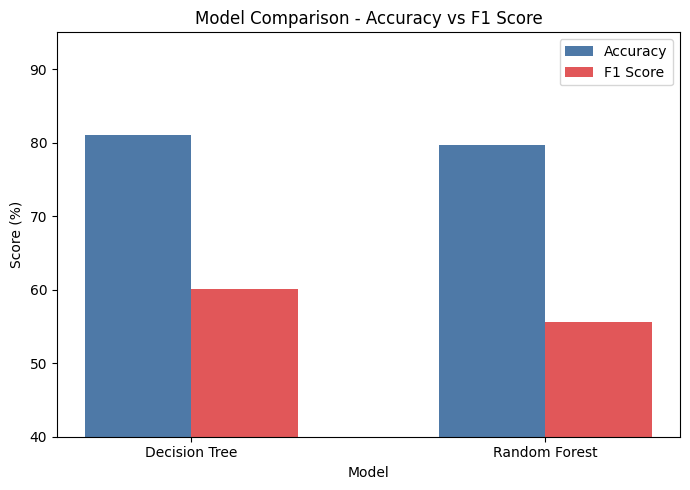

In [140]:
# CHART 8: Model Comparison - Accuracy and F1 Score (Bar Chart)

model_names     = ['Decision Tree', 'Random Forest']
accuracy_scores = [acc_dt, acc_rf]
f1_scores       = [f1_dt,  f1_rf]

print("--- Chart 8: Model Comparison ---")
print("Model                Accuracy   F1 Score")
print("Decision Tree       :", acc_dt, "% |", f1_dt, "%")
print("Random Forest       :", acc_rf, "% |", f1_rf, "%")
print()

x     = [0, 1]
width = 0.3

plt.figure(figsize=(7, 5))
plt.bar([i - width/2 for i in x], accuracy_scores, width=width, color='#4e79a7', label='Accuracy')
plt.bar([i + width/2 for i in x], f1_scores,       width=width, color='#e15759', label='F1 Score')
plt.xticks(x, model_names)
plt.title("Model Comparison - Accuracy vs F1 Score")
plt.xlabel("Model")
plt.ylabel("Score (%)")
plt.ylim(40, 95)
plt.legend()
plt.tight_layout()
plt.show()

Chart 9: Feature Importance (Random Forest)
TotalCharges                      0.186855
MonthlyCharges                    0.174386
tenure                            0.152600
Contract_Month-to-month           0.065936
InternetService_Fiber optic       0.034204
PaymentMethod_Electronic check    0.029421
gender                            0.028468
PaperlessBilling                  0.025923
Contract_Two year                 0.024002
Partner                           0.023924
OnlineBackup                      0.021703
OnlineSecurity                    0.021307
dtype: float64



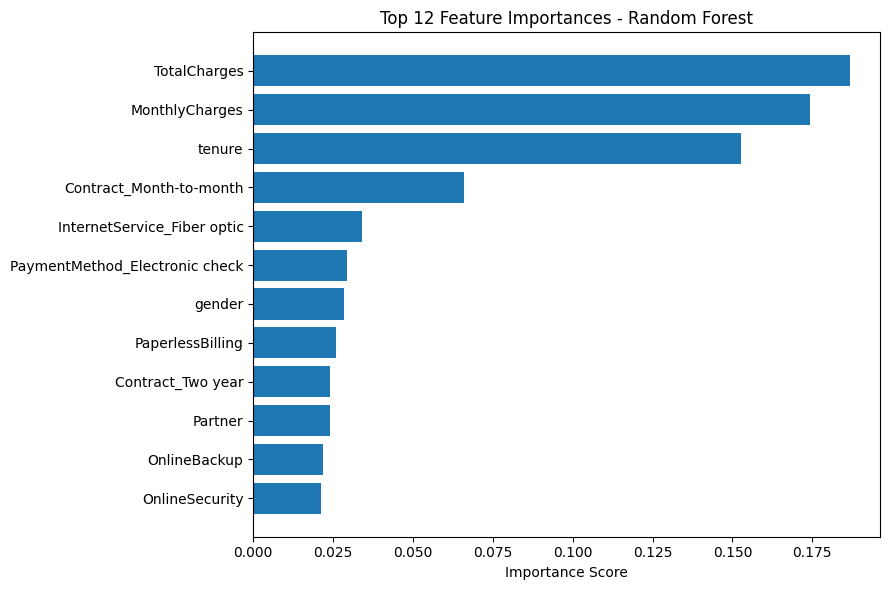

In [141]:
# CHART 9: Feature Importance - Random Forest (Bar Chart)

feature_names       = X.columns
feature_importances = model_rf.feature_importances_

importance_df  = pd.Series(feature_importances, index=feature_names)
importance_df  = importance_df.sort_values(ascending=False)
top12_features = importance_df.head(12)

print("Chart 9: Feature Importance (Random Forest)")
print(top12_features)
print()

plt.figure(figsize=(9, 6))
plt.barh(top12_features.index[::-1], top12_features.values[::-1])
plt.title("Top 12 Feature Importances - Random Forest")
plt.xlabel("Importance Score")
plt.tight_layout()
plt.show()